# 324 millones de años, 26 caracteres: así se decide si *Chosha* es un insecto

Un fósil del Carbonífero, en Texas, con patas abdominales en forma de remo. De los 58 caracteres anatómicos de la matriz filogenética, el fósil aporta **26**. Con eso hay que ubicarlo en el árbol de la vida.

El test que corrieron los propios autores la deja fuera de los crustáceos, aunque sin margen de sobra. Lo que **no** descarta es que sea un hexápodo que nunca llegó a insecto.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** Tihelka et al. (2026), *Amphibious stem-insect sheds light on colonization of land* — Nature
**DOI:** [10.1038/s41586-026-10961-2](https://doi.org/10.1038/s41586-026-10961-2)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-08-26-chosha-praecursor/notebook.ipynb)

**Video:** [Pendiente]

## El hueco de los hexápodos

Los relojes moleculares dicen que los insectos son viejísimos. El registro fósil no aparece para respaldarlos: hay un tramo largo del Paleozoico —el llamado *hexapod gap*— donde casi no hay fósiles de insectos que nadie discuta.

*Chosha praecursor* sale de la Formación Tesnus, en Texas, y el paper la fecha en unos 324 millones de años (Mississippiense tardío). Esa datación viene del artículo: **no está en los datos que abrimos aquí**.

Lo que sí está en los datos es el aparato con el que el equipo decidió dónde poner a *Chosha*: dos matrices de los mismos **58 caracteres** anatómicos —una de 23 taxa y otra recortada a 17—, cuatro análisis bayesianos (dos por matriz), dos de parsimonia sobre la grande y un test de topologías. Eso es lo que vamos a abrir.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
UMBRAL_P = 0.05   # nivel al que el test de topologías rechaza una hipótesis
FUENTE = ('Fuente: Tihelka et al. (2026), Nature | '
          'Datos: Zenodo 10.5281/zenodo.19565989')

COLOR_DATOS      = '#2563EB'   # azul CaM — hipótesis que sobreviven, anatomía externa
COLOR_ALERTA     = '#DC2626'   # rojo — hipótesis rechazadas, Chosha destacada
COLOR_SECUNDARIO = '#059669'   # verde esmeralda — taxa actuales
COLOR_REFERENCIA = '#D97706'   # ámbar — umbrales y anatomía interna o blanda
COLOR_CONTEXTO   = '#BBBBBB'   # gris

# ── Preparación ───────────────────────────────────────────────
import os
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'

style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

os.makedirs('figuras', exist_ok=True)
os.makedirs('datos', exist_ok=True)

CSVS = ['test_topologias', 'caracteres_chosha', 'completitud_taxa',
        'soportes_clado_fosil', 'convergencia_mcmc']
for nombre in CSVS:  # en Colab no existen todavía; en local ya están
    destino = f'datos/{nombre}.csv'
    if not os.path.exists(destino):
        urllib.request.urlretrieve(
            f'{BASE}/papers/2026-08-26-chosha-praecursor/datos/{nombre}.csv', destino)

# ── Carga ─────────────────────────────────────────────────────
sh      = pd.read_csv('datos/test_topologias.csv')
car     = pd.read_csv('datos/caracteres_chosha.csv')
comp    = pd.read_csv('datos/completitud_taxa.csv')
soporte = pd.read_csv('datos/soportes_clado_fosil.csv')
mcmc    = pd.read_csv('datos/convergencia_mcmc.csv')


def es(n, dec=1):
    """Formatea un número al estilo español: 1.298,04 y 44,8."""
    s = f'{n:,.{dec}f}'
    return s.replace(',', '@').replace('.', ',').replace('@', '.')


# ── Métrica derivada: completitud de codificación ─────────────
# DEFINICIÓN: porcentaje de los 58 caracteres de la matriz que un taxón tiene
# codificado con un estado (0, 1, 2...). Se descartan tanto los '?' (dato faltante)
# como los '-' (carácter inaplicable) — y ese segundo descarte solo toca a los taxa
# actuales, porque ningún fósil trae '-'. Es una simplificación didáctica nuestra,
# NO una métrica estándar en filogenética — ver la tabla de verificación al final.
N_CARACTERES = len(car)
N_EXTERNOS = int((car.tipo_anatomia == 'Externa').sum())
N_INTERNOS = N_CARACTERES - N_EXTERNOS

# El CSV trae una columna 'pct_de_los_58_externos' cuyo nombre no describe lo que
# contiene (el denominador real son los 33 externos, no 58). La recalculamos.
comp['pct_externos'] = comp.n_ext_codificados / N_EXTERNOS * 100

fosiles  = comp[comp.tipo == 'Fósil']
actuales = comp[comp.tipo == 'Actual']
chosha   = comp[comp.taxon == 'Chosha praecursor'].iloc[0]

cod_ext = int(car[(car.tipo_anatomia == 'Externa') & (car.codificado == 1)].shape[0])
cod_int = int(car[(car.tipo_anatomia != 'Externa') & (car.codificado == 1)].shape[0])

print(f'Matriz: {len(comp)} taxa x {N_CARACTERES} caracteres '
      f'({len(fosiles)} fósiles, {len(actuales)} actuales)')
print(f'Caracteres: {N_EXTERNOS} de anatomía externa, {N_INTERNOS} internos o blandos')
print()
print(f'Chosha praecursor: {int(chosha.n_codificados)}/{N_CARACTERES} caracteres '
      f'codificados = {es(chosha.pct_completitud)} %')
print(f'  externos          : {cod_ext}/{N_EXTERNOS} = {es(cod_ext / N_EXTERNOS * 100)} %')
print(f'  internos o blandos: {cod_int}/{N_INTERNOS} = {es(cod_int / N_INTERNOS * 100)} %')
print()
print(f'Test de topologías: {len(sh)} hipótesis, '
      f'{int(sh.rechazada_al_5pct.sum())} rechazadas al {es(UMBRAL_P * 100, 0)} %')
bayes_pct = soporte.loc[soporte.metodo.str.startswith('Bayesiano'), 'soporte_pct']
parsi_pct = soporte.loc[soporte.metodo.str.startswith('Parsimonia'), 'soporte_pct']
print(f'Soporte del clado de 4 fósiles ({len(soporte)} análisis, dos métricas distintas):')
print(f'  bayesiano (prob. posterior) : {es(bayes_pct.min())} % a {es(bayes_pct.max())} %')
print(f'  parsimonia (jackknife)      : {es(parsi_pct.min())} % a {es(parsi_pct.max())} %')

Matriz: 23 taxa x 58 caracteres (5 fósiles, 18 actuales)
Caracteres: 33 de anatomía externa, 25 internos o blandos

Chosha praecursor: 26/58 caracteres codificados = 44,8 %
  externos          : 25/33 = 75,8 %
  internos o blandos: 1/25 = 4,0 %

Test de topologías: 5 hipótesis, 3 rechazadas al 5 %
Soporte del clado de 4 fósiles (6 análisis, dos métricas distintas):
  bayesiano (prob. posterior) : 86,9 % a 92,9 %
  parsimonia (jackknife)      : 20,0 % a 66,7 %


Aquí está.

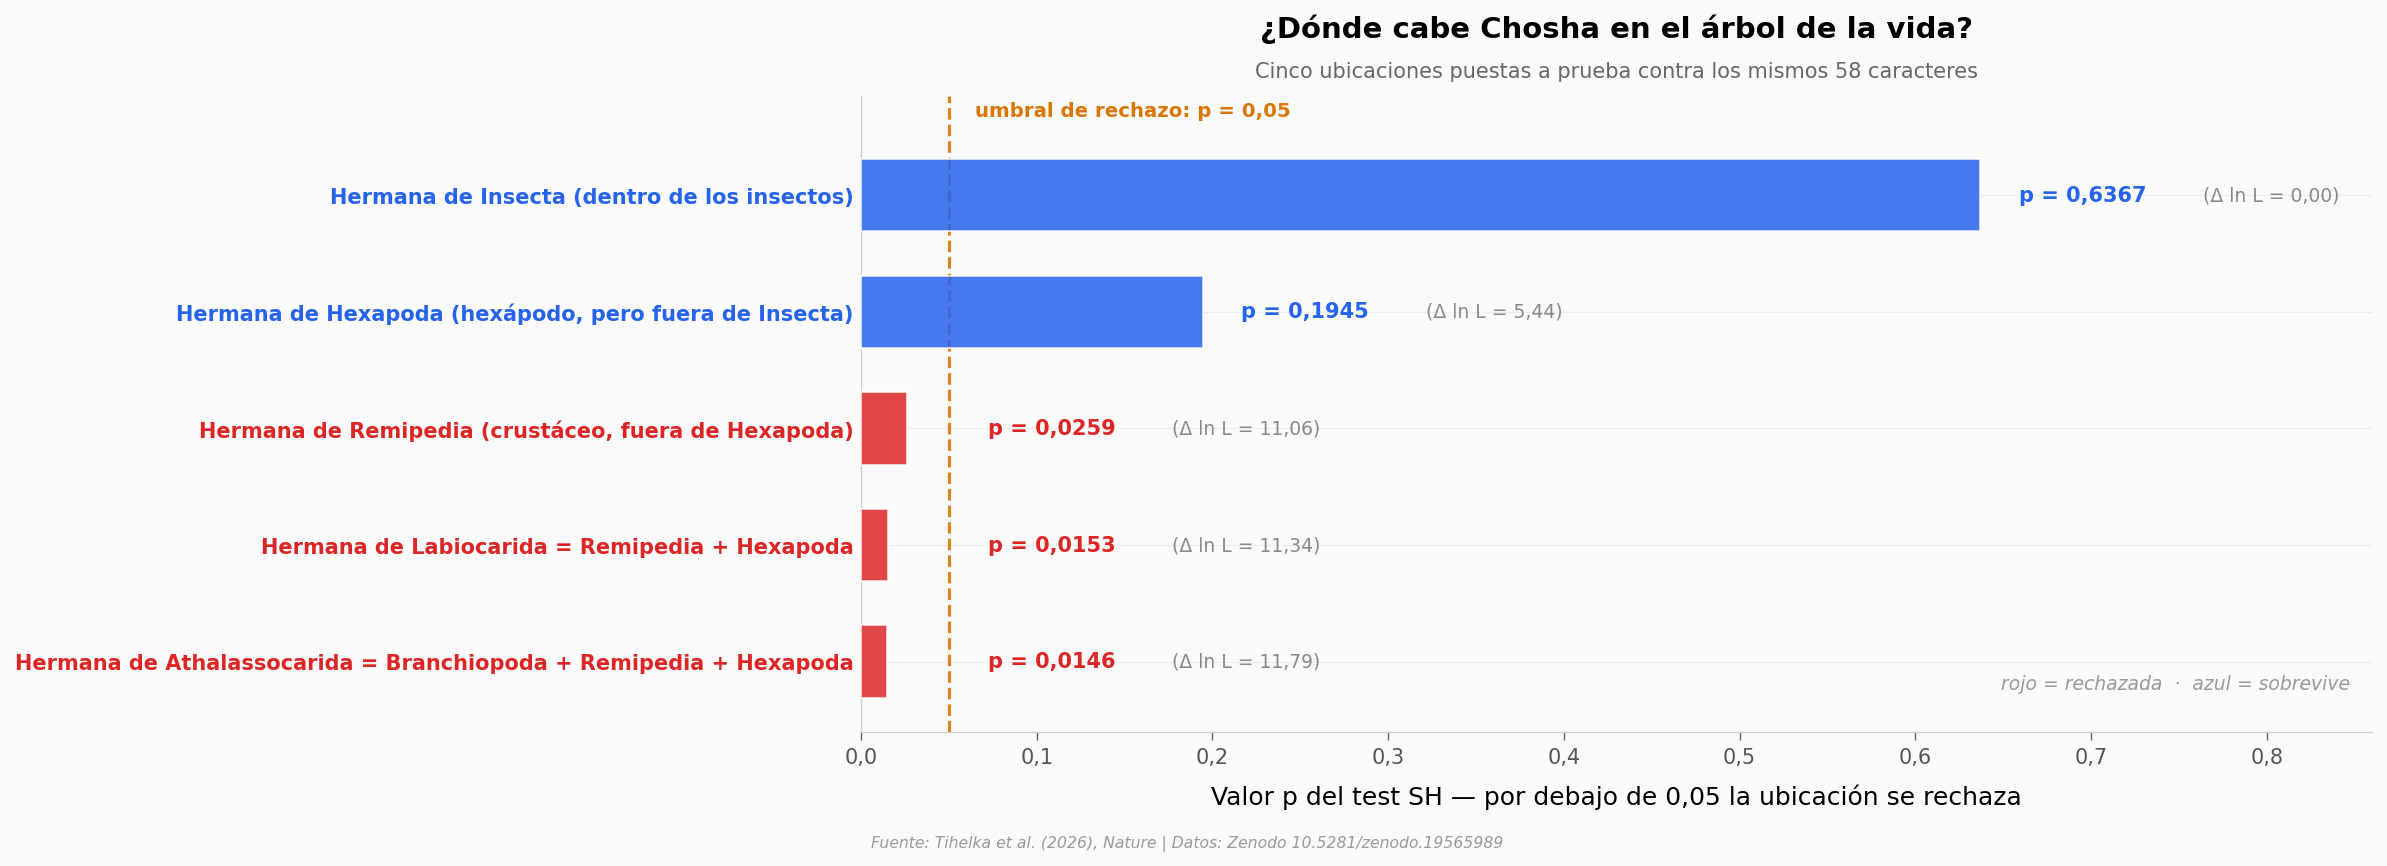

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

d = sh.sort_values('p_valor')           # las más improbables abajo
y = np.arange(len(d))
colores = [COLOR_ALERTA if r else COLOR_DATOS for r in d.rechazada_al_5pct]

ax.barh(y, d.p_valor, color=colores, alpha=0.85, height=0.62,
        edgecolor='white', linewidth=0.8, zorder=5)

for yi, (p, delta, rech) in enumerate(zip(d.p_valor, d.delta_ln_L, d.rechazada_al_5pct)):
    # las barras rechazadas son diminutas: se despeja la etiqueta más allá del umbral
    x_lab = max(p, UMBRAL_P) + 0.022
    ax.text(x_lab, yi, f'p = {es(p, 4)}', va='center', fontsize=10,
            fontweight='bold', color=COLOR_ALERTA if rech else COLOR_DATOS, zorder=6)
    ax.text(x_lab + 0.105, yi, f'(Δ ln L = {es(delta, 2)})', va='center',
            fontsize=9, color='#888888', zorder=6)

ax.axvline(UMBRAL_P, color=COLOR_REFERENCIA, linewidth=1.5, linestyle='--', alpha=0.9, zorder=4)
ax.text(UMBRAL_P + 0.015, len(d) - 0.28, f'umbral de rechazo: p = {es(UMBRAL_P, 2)}',
        fontsize=9.5, fontweight='bold', color=COLOR_REFERENCIA, va='center', ha='left')

ax.set_yticks(y)
ax.set_yticklabels(d.hipotesis, fontsize=10)
for tick, rech in zip(ax.get_yticklabels(), d.rechazada_al_5pct):
    tick.set_color(COLOR_ALERTA if rech else COLOR_DATOS)
    tick.set_fontweight('bold')

ax.set_xlim(0, 0.86)
ax.set_ylim(-0.6, len(d) - 0.15)
ax.set_xticks(np.arange(0, 0.9, 0.1))
ax.set_xticklabels([es(t, 1) for t in np.arange(0, 0.9, 0.1)])
ax.set_xlabel('Valor p del test SH — por debajo de 0,05 la ubicación se rechaza')
ax.set_title('¿Dónde cabe Chosha en el árbol de la vida?', fontsize=14,
             fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cinco ubicaciones puestas a prueba contra los mismos 58 caracteres',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.text(0.985, 0.06, 'rojo = rechazada  ·  azul = sobrevive',
        transform=ax.transAxes, fontsize=9, color='#999999',
        ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/test_topologias.png', dpi=200, bbox_inches='tight')
plt.show()

## Lo que el test cierra y lo que deja abierto

Las tres hipótesis rechazadas tienen algo en común: son exactamente las tres que sacan a *Chosha* de los hexápodos. Emparentarla con Remipedia (p = 0,0259), con Labiocarida (p = 0,0153) o con Athalassocarida (p = 0,0146) empeora el ajuste lo suficiente como para descartarlas. La puerta grande se cierra: los datos no aguantan que esto sea un crustáceo.

La puerta chica sigue abierta. La hipótesis "hexápodo, pero fuera de Insecta" pierde 5,44 unidades de verosimilitud frente a la mejor, y con eso **no** se rechaza: p = 0,1945. El abstract del paper lo dice con la palabra justa —*strongly favouring*, favorece con fuerza— y el test explica por qué esa palabra no es "demuestra".

Ojo con un detalle: el test se corrió con 19 taxa, dejando fuera a los otros cuatro fósiles de la matriz. Sus valores hablan de *Chosha* y de nadie más.

## ¿Por qué queda margen de duda?

La respuesta no está en el método. Está en el fósil.

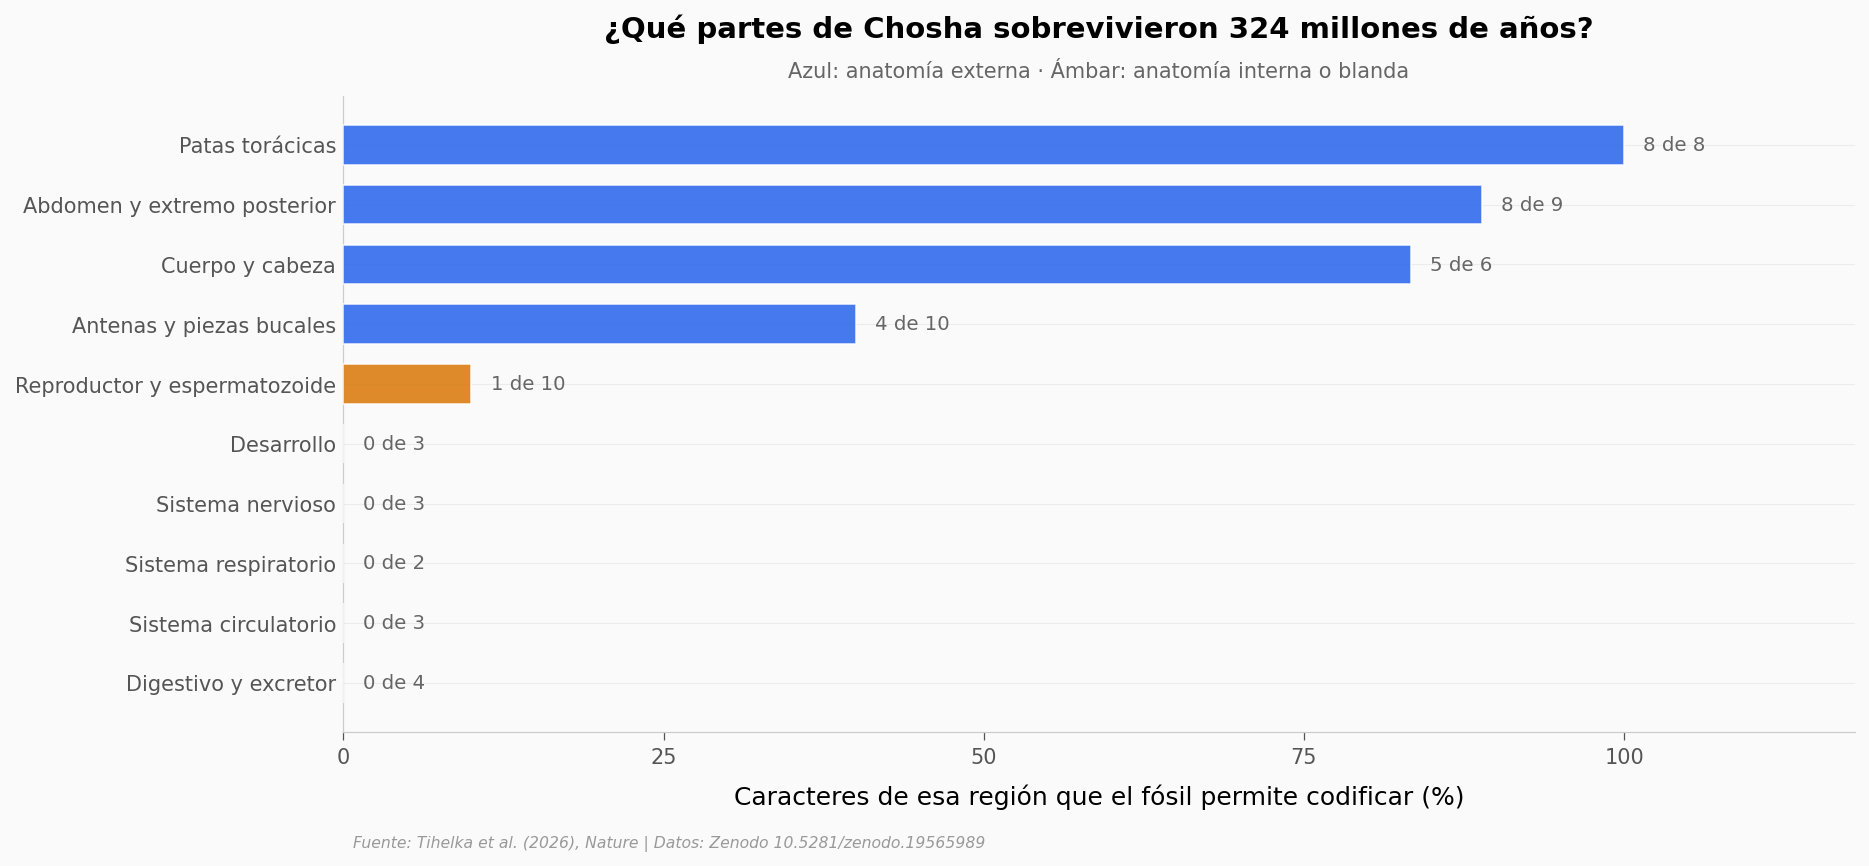

Anatomía externa   : 25/33 = 75,8 %
Interna o blanda   : 1/25 = 4,0 %


In [3]:
reg = (car.groupby('region', sort=False)
          .agg(codificados=('codificado', 'sum'),
               total=('codificado', 'size'),
               tipo=('tipo_anatomia', 'first'))
          .reset_index())
reg['pct'] = reg.codificados / reg.total * 100
reg = reg.sort_values('pct')

fig, ax = plt.subplots(figsize=(13, 5.5))
colores = [COLOR_DATOS if t == 'Externa' else COLOR_REFERENCIA for t in reg.tipo]
y = np.arange(len(reg))

ax.barh(y, reg.pct, color=colores, alpha=0.85, height=0.66,
        edgecolor='white', linewidth=0.8, zorder=5)
for yi, (p, c, t) in enumerate(zip(reg.pct, reg.codificados, reg.total)):
    ax.text(max(p, 0) + 1.5, yi, f'{c} de {t}', va='center', fontsize=9.5,
            color='#666666', zorder=6)

ax.set_yticks(y)
ax.set_yticklabels(reg.region, fontsize=10)
ax.set_xlim(0, 118)
ax.set_xticks([0, 25, 50, 75, 100])
ax.set_xlabel('Caracteres de esa región que el fósil permite codificar (%)')
ax.set_title('¿Qué partes de Chosha sobrevivieron 324 millones de años?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Azul: anatomía externa · Ámbar: anatomía interna o blanda',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/chosha_por_region.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Anatomía externa   : {cod_ext}/{N_EXTERNOS} = {es(cod_ext / N_EXTERNOS * 100)} %')
print(f'Interna o blanda   : {cod_int}/{N_INTERNOS} = {es(cod_int / N_INTERNOS * 100)} %')

## Una piedra no guarda un cerebro

Las patas torácicas están completas: 8 de 8. El abdomen, 8 de 9 — ahí viven el ovipositor y el filamento terminal que el paper señala como rasgos de insecto. Pero el sistema nervioso, el respiratorio, el circulatorio, el digestivo y el desarrollo van todos a cero. Ni un carácter.

Eso no es un descuido del equipo. Es lo que hace la fosilización: guarda cutícula y deja ir el resto. Y el hueco no se queda en lo blando: de los 8 caracteres externos que tampoco se pudieron codificar, 4 son de antenas y piezas bucales —el órgano de Johnston, la articulación basal de la mandíbula, la lacinia mobilis y el palpo de la primera maxila—. El archivo no dice qué significa cada estado, así que no podemos decir cuánto pesa cada ausencia; solo que están.

Vale la pena ver si esto le pasa solo a *Chosha* o si es la condición de todos los fósiles de la matriz. Y, de paso, cuánto aguanta el grupo que forman los cuatro fósiles cuando se lo mira con dos métodos distintos.

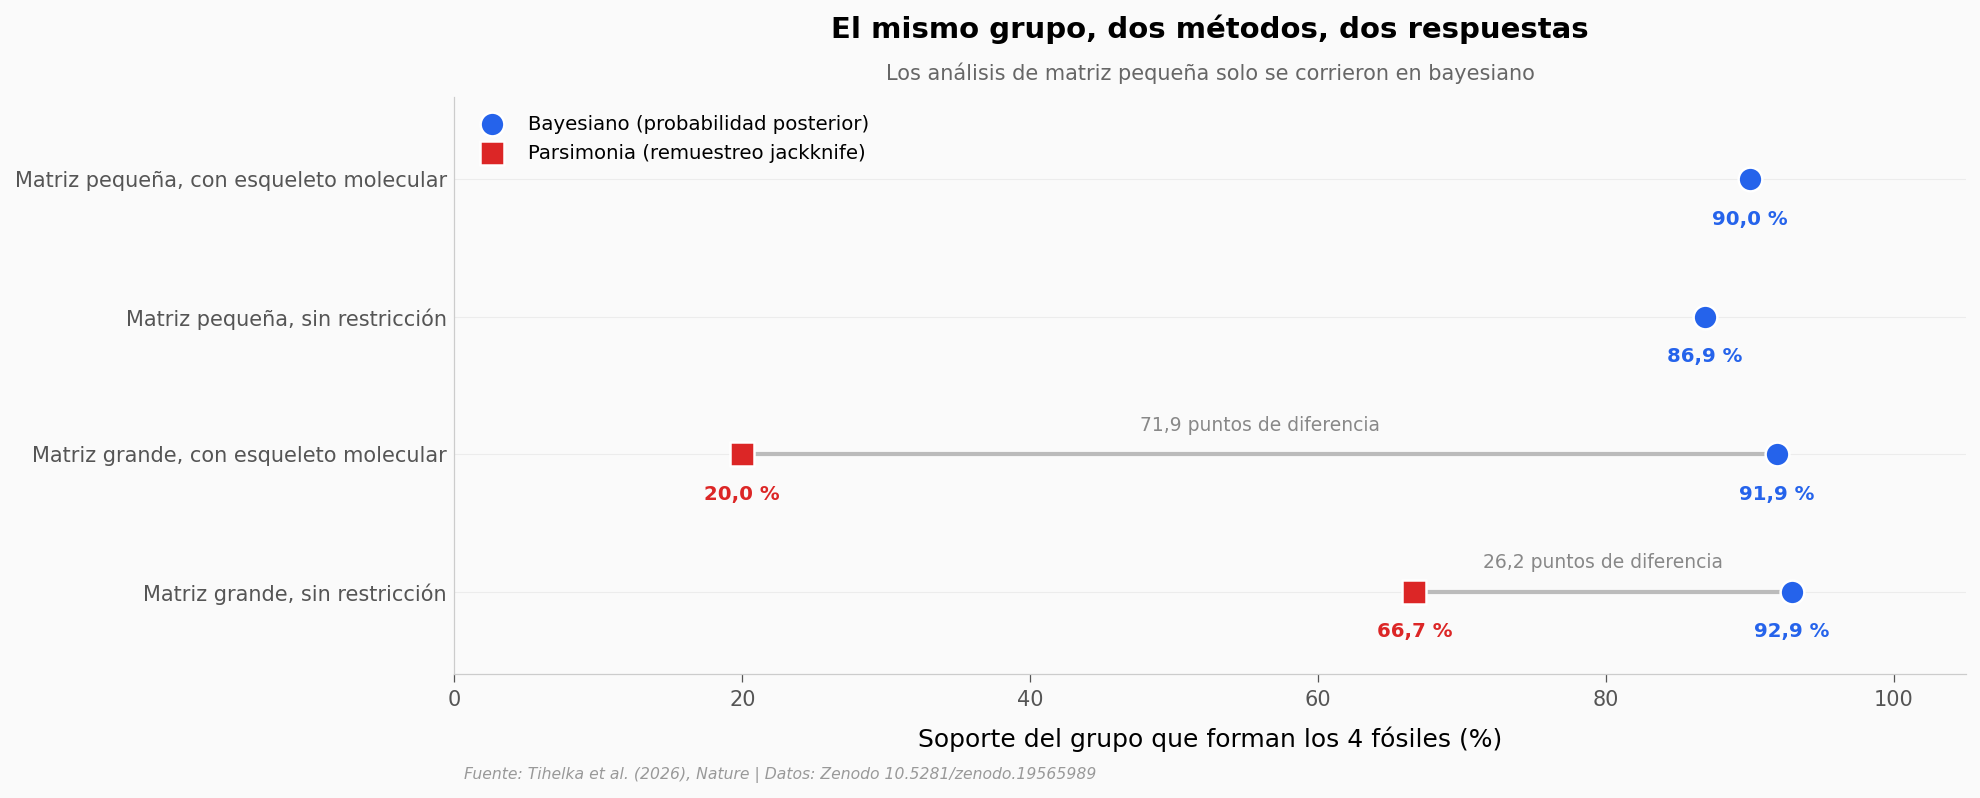

In [4]:
fig, ax = plt.subplots(figsize=(13, 5))

# 'backbone' es el único término sin traducir que traen los datos crudos
soporte['analisis'] = soporte.analisis.str.replace('backbone molecular',
                                                   'esqueleto molecular', regex=False)
analisis = list(dict.fromkeys(soporte.analisis))
pos = {a: i for i, a in enumerate(analisis)}
bayes = soporte[soporte.metodo.str.startswith('Bayesiano')]
parsi = soporte[soporte.metodo.str.startswith('Parsimonia')]

# línea que une los dos métodos donde ambos existen
for a in analisis:
    b = bayes[bayes.analisis == a]
    p = parsi[parsi.analisis == a]
    if len(b) and len(p):
        ax.plot([p.soporte_pct.iloc[0], b.soporte_pct.iloc[0]], [pos[a], pos[a]],
                color=COLOR_CONTEXTO, linewidth=2, zorder=3)
        gap = b.soporte_pct.iloc[0] - p.soporte_pct.iloc[0]
        ax.text((b.soporte_pct.iloc[0] + p.soporte_pct.iloc[0]) / 2, pos[a] + 0.17,
                f'{es(gap)} puntos de diferencia', fontsize=9, color='#888888',
                ha='center', zorder=4)

ax.scatter(bayes.soporte_pct, [pos[a] for a in bayes.analisis], color=COLOR_DATOS,
           s=130, marker='o', edgecolors='white', linewidths=1.2, zorder=5,
           label='Bayesiano (probabilidad posterior)')
ax.scatter(parsi.soporte_pct, [pos[a] for a in parsi.analisis], color=COLOR_ALERTA,
           s=130, marker='s', edgecolors='white', linewidths=1.2, zorder=5,
           label='Parsimonia (remuestreo jackknife)')

for _, r in soporte.iterrows():
    ax.text(r.soporte_pct, pos[r.analisis] - 0.22, f'{es(r.soporte_pct)} %',
            fontsize=9.5, fontweight='bold', ha='center', va='top',
            color=COLOR_DATOS if r.metodo.startswith('Bayesiano') else COLOR_ALERTA,
            zorder=6)

ax.set_yticks(range(len(analisis)))
ax.set_yticklabels(analisis, fontsize=10)
ax.set_ylim(-0.6, len(analisis) - 0.4)
ax.set_xlim(0, 105)
ax.set_xlabel('Soporte del grupo que forman los 4 fósiles (%)')
ax.set_title('El mismo grupo, dos métodos, dos respuestas', fontsize=14,
             fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Los análisis de matriz pequeña solo se corrieron en bayesiano',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(fontsize=9.5, loc='upper left', framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/soporte_clado.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Qué tan poco sabemos de un fósil?

El soporte bayesiano del grupo de cuatro fósiles va de 86,9 % a 92,9 % — alto. El remuestreo de parsimonia solo se corrió sobre la matriz grande, y ahí da 66,7 % en el análisis sin restricción y 20,0 % en el que lleva esqueleto molecular, frente a 92,9 % y 91,9 % bayesianos sobre esos mismos dos análisis. Ojo con la resta: no son la misma unidad —una es probabilidad posterior, la otra frecuencia de remuestreo, y la primera suele salir más alta—, así que lo que importa es el desacuerdo de veredicto, no el tamaño exacto del salto. Reportamos ambos porque quedarse con el favorable sería elegir el resultado, no leerlo.

Esa fragilidad tiene un origen medible. Pongamos a *Chosha* al lado de los otros 22 taxa.

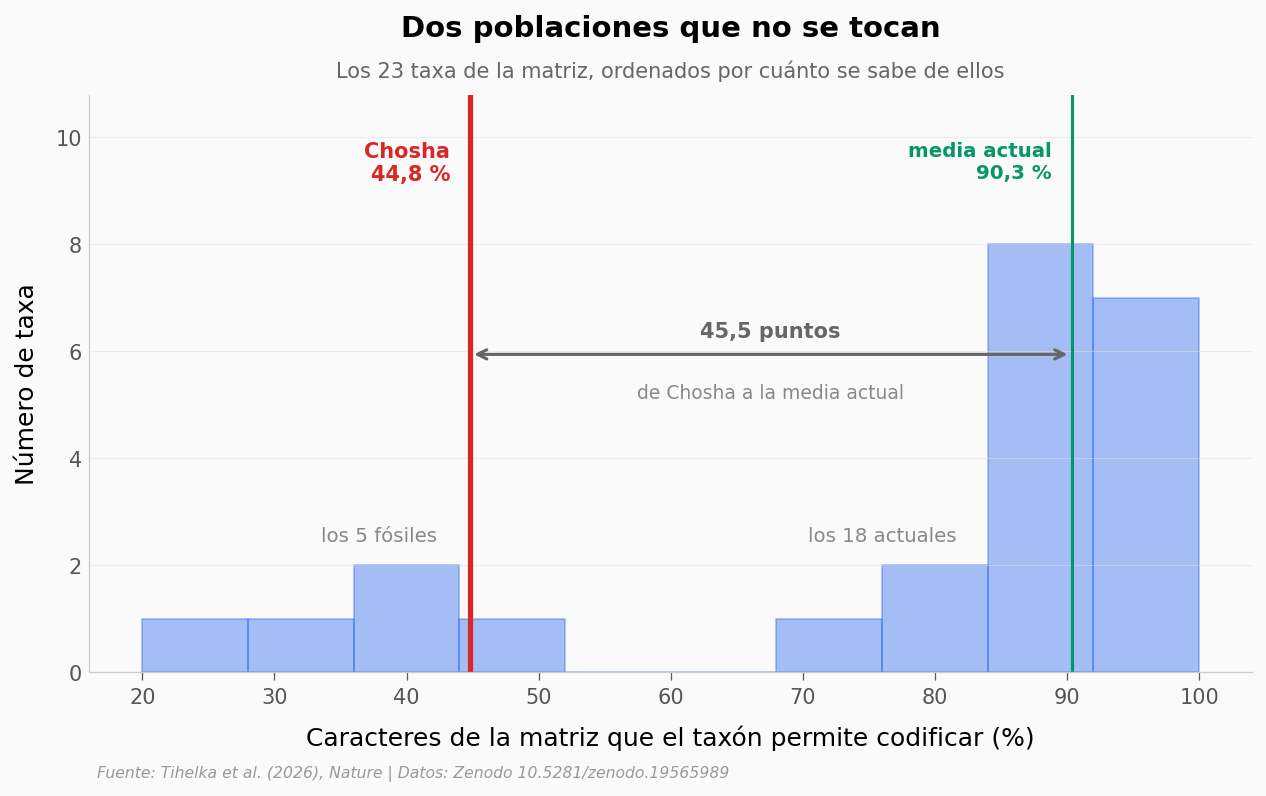

Fósiles  (n=5) : mediana 37,9 %, RIC 34,5-41,4 %, rango 27,6-44,8 %
Actuales (n=18): mediana 90,6 %, RIC 86,2-96,6 %, rango 75,9-100,0 %
Brecha entre el mejor fósil y el peor taxón actual: 31,1 puntos (sin solapamiento)
Asimetría -1,27, curtosis 0,09 (descriptivos: la bimodalidad la muestra el hueco vacío, no estos dos números)


In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

bins = np.arange(20, 105, 8)
n, _, _ = ax.hist(comp.pct_completitud, bins=bins, color=COLOR_DATOS, alpha=0.4,
                  edgecolor=COLOR_DATOS, linewidth=0.8)
y_max = n.max() * 1.35
ax.set_ylim(0, y_max)

media_actuales = actuales.pct_completitud.mean()
ax.axvline(media_actuales, color=COLOR_SECUNDARIO, linewidth=1.5)
ax.text(media_actuales - 1.5, y_max * 0.92, f'media actual\n{es(media_actuales)} %',
        fontsize=9.5, color=COLOR_SECUNDARIO, fontweight='bold', ha='right', va='top')

ax.axvline(chosha.pct_completitud, color=COLOR_ALERTA, linewidth=2.5)
ax.text(chosha.pct_completitud - 1.5, y_max * 0.92,
        f'Chosha\n{es(chosha.pct_completitud)} %',
        fontsize=10, color=COLOR_ALERTA, fontweight='bold', ha='right', va='top')

ax.annotate('', xy=(media_actuales, y_max * 0.55), xytext=(chosha.pct_completitud, y_max * 0.55),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((media_actuales + chosha.pct_completitud) / 2, y_max * 0.58,
        f'{es(media_actuales - chosha.pct_completitud)} puntos', fontsize=10,
        color='#666666', ha='center', fontweight='bold')
ax.text((media_actuales + chosha.pct_completitud) / 2, y_max * 0.50,
        'de Chosha a la media actual', fontsize=9, color='#888888', ha='center', va='top')

ax.text(fosiles.pct_completitud.median(), 2.45, 'los 5 fósiles',
        fontsize=9.5, color='#888888', ha='center')
ax.text(76, 2.45, 'los 18 actuales', fontsize=9.5, color='#888888', ha='center')

ax.set_xlabel('Caracteres de la matriz que el taxón permite codificar (%)')
ax.set_ylabel('Número de taxa')
ax.set_title('Dos poblaciones que no se tocan', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Los 23 taxa de la matriz, ordenados por cuánto se sabe de ellos',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/completitud_taxa.png', dpi=200, bbox_inches='tight')
plt.show()

brecha = actuales.pct_completitud.min() - fosiles.pct_completitud.max()
print(f'Fósiles  (n={len(fosiles)}) : mediana {es(fosiles.pct_completitud.median())} %, '
      f'RIC {es(fosiles.pct_completitud.quantile(.25))}-'
      f'{es(fosiles.pct_completitud.quantile(.75))} %, '
      f'rango {es(fosiles.pct_completitud.min())}-{es(fosiles.pct_completitud.max())} %')
print(f'Actuales (n={len(actuales)}): mediana {es(actuales.pct_completitud.median())} %, '
      f'RIC {es(actuales.pct_completitud.quantile(.25))}-'
      f'{es(actuales.pct_completitud.quantile(.75))} %, '
      f'rango {es(actuales.pct_completitud.min())}-{es(actuales.pct_completitud.max())} %')
print(f'Brecha entre el mejor fósil y el peor taxón actual: {es(brecha)} puntos (sin solapamiento)')
print(f'Asimetría {es(comp.pct_completitud.skew(), 2)}, '
      f'curtosis {es(comp.pct_completitud.kurtosis(), 2)} '
      f'(descriptivos: la bimodalidad la muestra el hueco vacío, no estos dos números)')

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| El análisis ubica a *Chosha* dentro de Hexapoda | ✅ | Las 3 topologías que la sacan de Hexapoda se rechazan (p = 0,0259 / 0,0153 / 0,0146). Las 2 que la dejan dentro sobreviven |
| La evidencia favorece con fuerza que sea un insecto temprano | ⚠️ | La hipótesis "hermana de Insecta" tiene la mejor verosimilitud (ln L = −1.298,04) y p = 0,6367, **pero** la alternativa "hexápodo fuera de Insecta" no se rechaza (p = 0,1945). Favorecida, no confirmada — el abstract dice *strongly favouring* (favorece con fuerza), no *demonstrates* (demuestra) |
| *Chosha* es el fósil mejor codificado de la matriz | ✅ | 26 de 58 caracteres (44,8 %), por encima de *Dasyleptus* (41,4 %) y de *Leverhulmia* (27,6 %) |
| Lo que se conserva es la anatomía externa | ✅ | 25 de 33 caracteres externos (75,8 %) frente a 1 de 25 internos o blandos (4,0 %). Sistema nervioso, respiratorio, circulatorio, digestivo y desarrollo: 0 caracteres |
| El grupo de los 4 fósiles tiene soporte alto | ⚠️ | Depende del método: bayesiano 86,9–92,9 %, remuestreo de parsimonia 20,0–66,7 %. En la matriz grande con esqueleto molecular el mismo grupo pasa de 91,9 % bayesiano a 20,0 % de remuestreo. Las dos cifras no son la misma unidad, así que lo que cuenta es el desacuerdo de veredicto, no el tamaño del salto |
| Las cadenas bayesianas convergieron | ✅ | PSRF —el indicador de que las cadenas terminaron en el mismo sitio— entre 0,9984 y 1,0015 (el objetivo es ~1,00) y tamaño efectivo de muestra mínimo entre 125,9 y 301,0 en los 4 análisis |
| El fósil tiene ovipositor y filamento terminal | ⚠️ | Los caracteres 30 y 32 aparecen codificados en la matriz, lo cual es consistente con el paper. Pero el archivo no trae etiquetas de estado: podemos ver **que** están codificados, no **qué** significa cada estado |
| Unos 324 millones de años, Formación Tesnus | ❌ | La datación y la geología no están en este repositorio. Es información del artículo, no verificable aquí |
| Modo de vida semiacuático | ❌ | Es una inferencia del equipo a partir de la morfología de los apéndices abdominales. El abstract la enuncia como sugerencia y solo para *algunos* insectos del linaje troncal (*stem-insects*); los datos de este repositorio no la tocan |
| "Los insectos más antiguos sin discusión" | ❌ | Requiere comparar contra el registro fósil completo, que no está en el dataset. Es un planteamiento de los autores |

> **Limitaciones**
>
> - **La matriz no trae etiquetas de estado.** El archivo nombra los 58 caracteres pero no dice qué significa el estado "0" o el "4". Todo lo que decimos aquí es sobre *cuántos* caracteres se pudieron codificar, nunca sobre qué dicen.
> - **La completitud de codificación es una simplificación didáctica nuestra**, no una métrica estándar en filogenética. Un análisis formal pondera cada carácter por su informatividad y modela reversiones; nosotros solo contamos cuántos caracteres traen un estado, descartando tanto los "?" (dato faltante) como los "-" (carácter inaplicable, por ejemplo "subdivisión del tarso" en un taxón que no tiene tarso). Ese segundo descarte solo afecta a los taxa actuales —los 5 fósiles no tienen ni un "-"—, así que estrecha artificialmente la distancia fósil/actual. Sirve para ver la asimetría, no para medir calidad filogenética.
> - **El test de topologías se corrió con 19 taxa**, excluyendo a *Leverhulmia*, a los dos ejemplares de Mazon Creek y a *Dasyleptus*. Sus valores hablan únicamente de la ubicación de *Chosha*.
> - **Cinco fósiles no son una muestra.** Toda la comparación fósil/actual descansa en n = 5 de un lado y n = 18 del otro.
> - **Este es un análisis comparativo, no experimental.** Nadie manipuló nada: se codificaron caracteres y se ajustaron modelos. Ninguna de estas cifras dice qué *causó* la forma de *Chosha*.

## Ahora tú

1. **¿Y si el umbral fuera más exigente?** El test rechaza al 5 %. Cambia `UMBRAL_P` en la celda de configuración a `0.01` y vuelve a correr la gráfica: ¿siguen cayendo las tres hipótesis de fuera de Hexapoda? Pista: mira `sh.p_valor < UMBRAL_P`.

2. **¿La brecha entre fósiles y actuales es real o es un artefacto de lo que no se fosiliza?** Repite el histograma con `comp.pct_externos` en vez de `comp.pct_completitud`. Ahí solo cuentan los 33 caracteres externos. ¿Se mantienen las dos poblaciones separadas?

3. **¿Cuánto sabemos de la parte del cuerpo que decide la pregunta?** Filtra `car` por `region == 'Abdomen y extremo posterior'` — es donde viven el ovipositor y el filamento terminal — y mira cuántos de esos 9 caracteres tiene codificados *Chosha*.

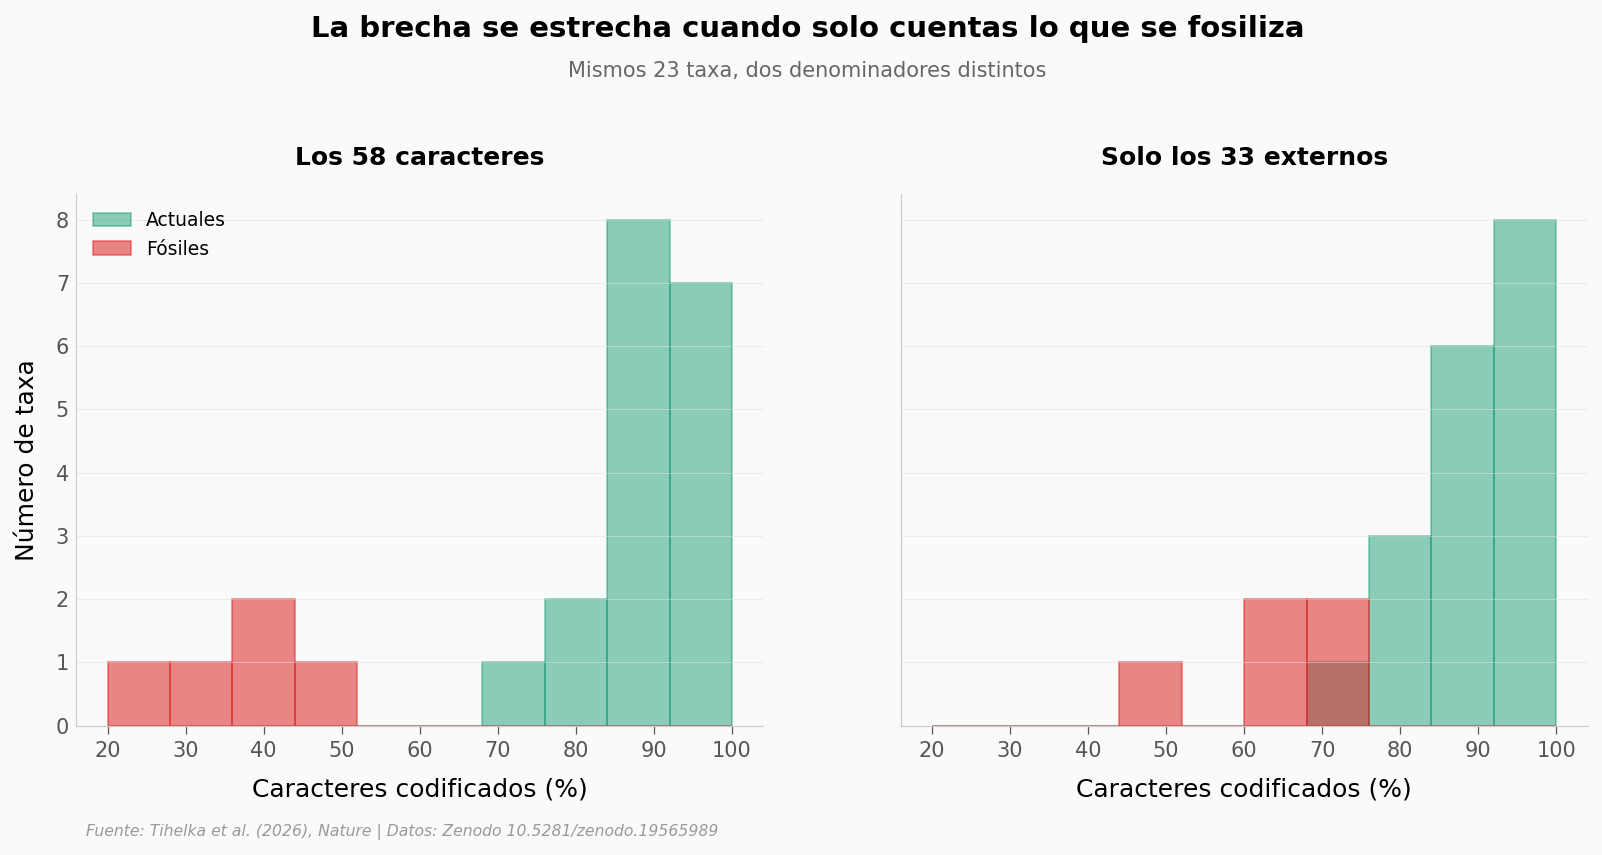

Con los 58 caracteres: mejor fósil 44,8 % vs peor actual 75,9 % -> brecha de 31,1 puntos
Con solo los 33 externos: mejor fósil 75,8 % vs peor actual 72,7 % -> solapan 3,0 puntos


In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 2: ¿la brecha fósil/actual sobrevive si solo contamos
# lo que puede fosilizar (los 33 caracteres de anatomía externa)?

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharey=True)
bins = np.arange(20, 105, 8)

for ax, col, titulo in zip(
        axes,
        ['pct_completitud', 'pct_externos'],
        [f'Los {N_CARACTERES} caracteres', f'Solo los {N_EXTERNOS} externos']):
    ax.hist(comp.loc[comp.tipo == 'Actual', col], bins=bins, color=COLOR_SECUNDARIO,
            alpha=0.45, edgecolor=COLOR_SECUNDARIO, linewidth=0.8, label='Actuales')
    ax.hist(comp.loc[comp.tipo == 'Fósil', col], bins=bins, color=COLOR_ALERTA,
            alpha=0.55, edgecolor=COLOR_ALERTA, linewidth=0.8, label='Fósiles')
    ax.set_title(titulo, fontsize=12, fontweight='bold', pad=14)
    ax.set_xlabel('Caracteres codificados (%)')

axes[0].set_ylabel('Número de taxa')
axes[0].legend(fontsize=9, loc='upper left', framealpha=0.9)
fig.suptitle('La brecha se estrecha cuando solo cuentas lo que se fosiliza',
             fontsize=14, fontweight='bold', y=1.14)
fig.text(0.5, 1.05, 'Mismos 23 taxa, dos denominadores distintos',
         fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.05, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/experimento_externos.png', dpi=200, bbox_inches='tight')
plt.show()

for col, etiqueta in [('pct_completitud', f'los {N_CARACTERES} caracteres'),
                      ('pct_externos', f'solo los {N_EXTERNOS} externos')]:
    mejor_fosil = comp.loc[comp.tipo == 'Fósil', col].max()
    peor_actual = comp.loc[comp.tipo == 'Actual', col].min()
    dif = peor_actual - mejor_fosil
    estado = f'brecha de {es(dif)} puntos' if dif > 0 else f'solapan {es(-dif)} puntos'
    print(f'Con {etiqueta}: mejor fósil {es(mejor_fosil)} % vs '
          f'peor actual {es(peor_actual)} % -> {estado}')

---

## Fuentes

**Paper**: [Amphibious stem-insect sheds light on colonization of land](https://doi.org/10.1038/s41586-026-10961-2)  
*Nature, 2026-08-26 · paywall*

**Dataset canónico**: [Data accompanying "Amphibious stem-insects shed light on colonisation of land"](https://doi.org/10.5281/zenodo.19565989)  
*Zenodo — matrices Nexus, salidas de MrBayes y TreeSearch, y el código R del test de topologías*

*20 afirmaciones del notebook verificadas contra estas fuentes*